### Count-Min Sketch

In [1]:
from hashlib import sha256
import math
import random
import numpy as np
import datetime
import matplotlib.pyplot as plt
import unittest
from collections import Counter


In [2]:
def date_generator():
    # Точка отсчета
    start_date = datetime.datetime(2000, 1, 1)
    
    while True:
        # Генерируем случайное смещение в секундах (на ~100 лет вперед)
        random_seconds = random.randint(0, 31536000 * 100)
        current_date = start_date + datetime.timedelta(seconds=random_seconds)
        
        # yield возвращает значение и "замораживает" функцию до следующего вызова
        yield current_date.isoformat()

In [3]:
class CMS:
    def __init__(self, d: int = 0, w: int = 0, eps: float = 0, delta: float = 0):
        # Сохраняем eps и delta, чтобы они были доступны в других методах
        self.eps = eps
        self.delta = delta
        
        if eps != 0 and delta != 0:
            self.w = int(math.ceil(math.e / eps))
            self.d = int(math.ceil(math.log(1 / delta)))
        else:
            self.d = d 
            self.w = w
            
        self.matrix = np.zeros((self.d, self.w), dtype=np.int64)
        self.salts = [str(i).encode() for i in range(self.d)]

    def _hash(self, item, i):
        """Реализация через SHA-256 с солью i-й строки"""
        data = self.salts[i] + str(item).encode()
        
        hash_object = sha256(data)
        hash_hex = hash_object.hexdigest()
        
        return int(hash_hex, 16) % self.w
    
    def add(self, item):
        for i in range(self.d):
            item_position = self._hash(item, i)
            self.matrix[i][item_position] += 1
        
    def estimate(self, item):
        return min(self.matrix[i][self._hash(item, i)] for i in range(self.d))
    
    def merge(self, other):
        if self.w != other.w or self.d != other.d:
            raise ValueError("Размеры таблиц должны совпадать!")
        
        # Создаем новый объект, передавая уже готовые w и d
        merged_cms = CMS(d=self.d, w=self.w, eps=self.eps, delta=self.delta)
        
        # Складываем матрицы
        merged_cms.matrix = self.matrix + other.matrix
        
        return merged_cms
            


In [4]:

class TestCMSAccuracy(unittest.TestCase):
    def run_benchmark(self, name, size):
        print(f"\n--- Тестирование потока {name} ({size} элементов) ---")
        
        # Генерируем данные
        gen = date_generator()
        stream = [next(gen) for _ in range(size)]
        true_counts = Counter(stream)
        
        # Настройки точности (например, epsilon = 0.001)
        eps, delta = 0.001, 0.05
        
        # Создаем две реализации (Пункт 2)
        cms1 = CMS(eps=eps, delta=delta)
        cms2 = CMS(eps=eps, delta=delta)
        
        # Делим поток пополам
        mid = size // 2
        for x in stream[:mid]: cms1.add(x)
        for x in stream[mid:]: cms2.add(x)
        
        # Объединяем их (Пункт 3)
        merged = cms1.merge(cms2)
        
        # Считаем погрешность
        diffs = []
        for x, real in true_counts.most_common(500): # смотрим топ-500 популярных дат
            est = merged.estimate(x)
            diffs.append(est - real)
        
        avg_abs_err = np.mean(diffs)
        max_abs_err = np.max(diffs)
        
        print(f"Средняя абс. погрешность: {avg_abs_err:.2f}")
        print(f"Макс. абс. погрешность: {max_abs_err:.2f}")
        
        # Теоретический порог ошибки: epsilon * N
        theoretical_limit = eps * size
        print(f"Теоретический порог (eps * N): {theoretical_limit:.2f}")
        
        self.assertLessEqual(avg_abs_err, theoretical_limit)

    def test_norm(self):
        # 250 000 элементов
        self.run_benchmark("NORM", 250000)

    def test_big(self):
        # 1 150 000 элементов
        self.run_benchmark("BIG", 1150000)

In [5]:
unittest.main(argv=['first-arg-is-ignored'], exit=False)


--- Тестирование потока BIG (1150000 элементов) ---


.

Средняя абс. погрешность: 404.72
Макс. абс. погрешность: 439.00
Теоретический порог (eps * N): 1150.00

--- Тестирование потока NORM (250000 элементов) ---


.
----------------------------------------------------------------------
Ran 2 tests in 7.417s

OK


Средняя абс. погрешность: 84.46
Макс. абс. погрешность: 104.00
Теоретический порог (eps * N): 250.00


Epsilon    | Width (w)  | Rows (d) | Avg Abs Err  | Avg Rel Err
-----------------------------------------------------------------
0.1        | 28         | 3        | 5296.96      | 5234.9900 
0.05       | 55         | 3        | 2673.73      | 2642.3650 
0.02       | 136        | 3        | 1074.63      | 1062.2083 
0.01       | 272        | 3        | 531.32       | 525.1367  
0.005      | 544        | 3        | 261.26       | 258.2500  
0.002      | 1360       | 3        | 101.02       | 99.8417   
0.001      | 2719       | 3        | 49.35        | 48.7983   


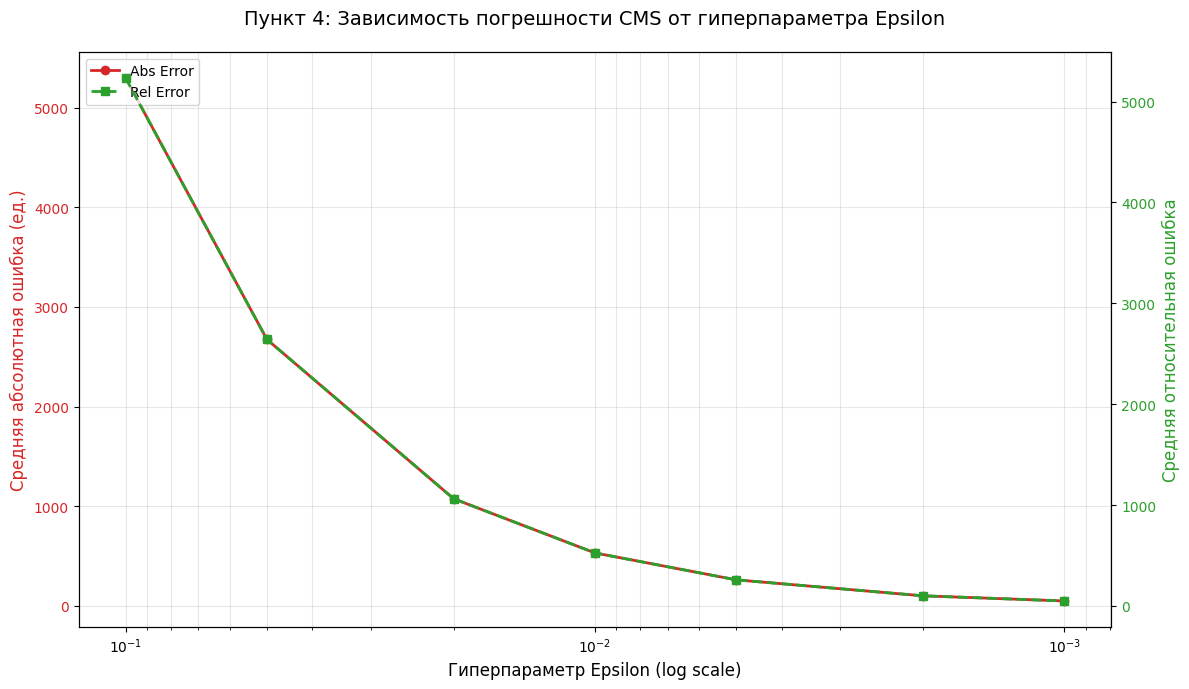

In [6]:
def run_final_analysis():
    # 1. Подготовка данных для анализа (фиксированный поток 150 000 элементов)
    N = 150000
    gen = date_generator()
    data = [next(gen) for _ in range(N)]
    true_counts = Counter(data)
    
    # Диапазон epsilon: от низкой точности (0.1) до высокой (0.001)
    eps_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
    delta_fixed = 0.05
    
    abs_errors = []
    rel_errors = []
    widths = []

    print(f"{'Epsilon':<10} | {'Width (w)':<10} | {'Rows (d)':<8} | {'Avg Abs Err':<12} | {'Avg Rel Err':<10}")
    print("-" * 65)

    # 2. Сбор статистики по разным гиперпараметрам
    for e in eps_values:
        # Создаем CMS с текущим epsilon (delta фиксирована)
        cms = CMS(eps=e, delta=delta_fixed)
        for x in data:
            cms.add(x)
        
        # Считаем ошибки для топ-300 элементов (самых частых)
        sample_keys = [k for k, v in true_counts.most_common(300)]
        
        current_abs = []
        current_rel = []
        
        for k in sample_keys:
            real = true_counts[k]
            est = cms.estimate(k)
            err = est - real
            current_abs.append(err)
            current_rel.append(err / real if real > 0 else 0)
        
        avg_abs = np.mean(current_abs)
        avg_rel = np.mean(current_rel)
        
        abs_errors.append(avg_abs)
        rel_errors.append(avg_rel)
        widths.append(cms.w)
        
        print(f"{e:<10} | {cms.w:<10} | {cms.d:<8} | {avg_abs:<12.2f} | {avg_rel:<10.4f}")

    # 3. Построение совмещенного графика
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Левая ось: Абсолютная ошибка (Красная линия)
    color_abs = 'tab:red'
    ax1.set_xlabel('Гиперпараметр Epsilon (log scale)', fontsize=12)
    ax1.set_ylabel('Средняя абсолютная ошибка (ед.)', color=color_abs, fontsize=12)
    line1 = ax1.plot(eps_values, abs_errors, color=color_abs, marker='o', linewidth=2, label='Abs Error')
    ax1.tick_params(axis='y', labelcolor=color_abs)
    ax1.set_xscale('log')
    ax1.invert_xaxis() # Меньший epsilon (высокая точность) будет справа
    ax1.grid(True, which="both", ls="-", alpha=0.3)

    # Правая ось: Относительная ошибка (Зеленая линия)
    ax2 = ax1.twinx() 
    color_rel = 'tab:green'
    ax2.set_ylabel('Средняя относительная ошибка', color=color_rel, fontsize=12)
    line2 = ax2.plot(eps_values, rel_errors, color=color_rel, marker='s', linestyle='--', linewidth=2, label='Rel Error')
    ax2.tick_params(axis='y', labelcolor=color_rel)

    # Заголовок и легенда
    plt.title('Пункт 4: Зависимость погрешности CMS от гиперпараметра Epsilon', fontsize=14, pad=20)
    
    # Объединение легенд в одну
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

# Запуск анализа
run_final_analysis()